 # Importations et Structures de base
  Cette première partie prépare l'environnement technique du projet.
   * Bibliothèques : Utilisation de numpy pour les calculs, matplotlib pour les graphiques, et des modules standards
     comme math, random et csv.
   * Classe Ville : Définit une ville par son nom et ses coordonnées cartésiennes $(x, y)$.
   * Fonctions Géométriques :
       * duree_trajet : Calcule la distance euclidienne entre deux villes.
       * construire_matrice : Génère une matrice de distances pré-calculée pour accélérer l'algorithme.
   * Chargement des données : Fonctions dédiées au parsing de fichiers CSV (notamment pour les datasets de type Solomon
     ou TSP), avec gestion des limites de taille (chunks).

In [2]:
import math
import csv
import json
import random
import os
from pathlib import Path
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D


# ─────────────────────────────────────────────
# Structures de base (fournies)
# ─────────────────────────────────────────────

class Ville:
    def __init__(self, nom: str, x: float, y: float):
        self.nom = nom
        self.x   = x
        self.y   = y
    def __repr__(self):
        return self.nom


def duree_trajet(a: Ville, b: Ville) -> float:
    return math.sqrt((a.x - b.x) ** 2 + (a.y - b.y) ** 2)


def construire_matrice(villes: list) -> list:
    n = len(villes)
    return [[duree_trajet(villes[i], villes[j]) for j in range(n)] for i in range(n)]


def charger_villes_json(chemin_json: str) -> list[Ville]:
    """Charge les villes depuis un fichier JSON (format tsptwd)."""
    with open(chemin_json, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    scale = data.get('meta', {}).get('scale', 1.0)
    nodes = [data['depot']] + data['clients']
    villes = []
    for node in nodes:
        villes.append(Ville(node['nom'], float(node['x']) * scale, float(node['y']) * scale))
    return villes


def charger_villes_csv_tsp(chemin_csv, chunk_size) -> list:
    """Parser pour tsp_dataset.csv dont les coords sont stockées comme [[x,y],[x,y],...]"""
    import ast
    csv.field_size_limit(10_000_000)
    villes = []
    with open(chemin_csv, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            coords_str = row.get('city_coordinates')
            if not coords_str:
                continue
            try:
                coords = ast.literal_eval(coords_str)
                for point in coords:
                    idx = len(villes)
                    villes.append(Ville(f"Ville {idx}", float(point[0]), float(point[1])))
                    if len(villes) >= chunk_size:
                        return villes
            except Exception:
                continue
    return villes


def collect_solomon_dataset(raw_dir: Path):
    groupes = {}
    solomon_dir = raw_dir / "chunks" / "solomon_dataset"
    if not solomon_dir.exists():
        return groupes
    for sub in sorted(solomon_dir.iterdir()):
        if sub.is_dir():
            fichiers = sorted(sub.glob("*.csv"))
            if fichiers:
                groupes[sub.name] = fichiers
    return groupes


def charger_villes_depuis_split(chunk_size: int = 20, source: str = "solomon", n_json: int = 10) -> list:
    raw_dir = Path("./dataset_raw")

    if source == "solomon":
        groupes = collect_solomon_dataset(raw_dir)
        tous_les_fichiers = []
        for fichiers in groupes.values():
            tous_les_fichiers.extend(fichiers)
        if not tous_les_fichiers:
            raise FileNotFoundError("Aucun fichier Solomon trouvé dans dataset_raw")
        villes = []
        for chemin_csv in tous_les_fichiers:
            with open(chemin_csv, newline='', encoding='utf-8') as f:
                reader = csv.reader(f)
                next(reader)
                for row in reader:
                    if len(row) < 3:
                        continue
                    idx = len(villes)
                    villes.append(Ville(f"Ville {idx}", float(row[1]), float(row[2])))
                    if len(villes) >= chunk_size:
                        return villes
        return villes

    elif source == "tsp":
        tsp_src = raw_dir / "chunks" / "tsp_dataset" / "tsp_dataset.csv"
        if not tsp_src.exists():
            raise FileNotFoundError(f"Fichier TSP introuvable : {tsp_src.resolve()}")
        return charger_villes_csv_tsp(tsp_src, chunk_size)

    elif source == "json":
        json_path = Path(f"datasets/tsptwd_n{n_json}.json")
        if not json_path.exists():
            raise FileNotFoundError(f"Fichier JSON introuvable : {json_path}")
        return charger_villes_json(str(json_path))

    raise ValueError(f"Source inconnue : '{source}'. Valeurs acceptées : 'solomon', 'tsp', 'json'")


def charger_villes_csv(chemin_csv):
    villes = []
    with open(chemin_csv, newline='', encoding='utf-8') as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) < 3:
                continue
            nom = f"Ville {row[0]}"
            x = float(row[1])
            y = float(row[2])
            villes.append(Ville(nom, x, y))
    return villes


def charger_villes_depuis_dossiers(nb_fichiers):
    base_path = r"dataset_split\split_60_20_20\test\solomon_dataset"
    villes = []
    fichiers_pris = 0
    for dossier in sorted(os.listdir(base_path)):
        dossier_path = os.path.join(base_path, dossier)
        if os.path.isdir(dossier_path):
            for fichier in sorted(os.listdir(dossier_path)):
                if fichier.endswith(".csv"):
                    chemin_csv = os.path.join(dossier_path, fichier)
                    villes += charger_villes_csv(chemin_csv)
                    fichiers_pris += 1
                    if fichiers_pris >= nb_fichiers:
                        return villes
    return villes


# Représentation d'un Tour et Utilitaires
  Ici, on définit comment une solution (un chemin) est manipulée.
   * Classe Tour :
       * Stocke l'ordre de visite des villes.
       * Calcule le coût total (distance) du circuit.
       * Génère des tables d'adjacence (quels nœuds sont reliés), indispensables pour l'opérateur EAX.
   * Initialisation de la population :
       * generer_tour_aleatoire : Crée des solutions de départ au hasard.
       * generer_tour_greedy : Utilise une heuristique du "plus proche voisin" pour fournir des points de départ de
         qualité supérieure à l'aléatoire pur.

In [3]:
class Tour:
    """
    Un tour est une permutation des indices de villes.
    On stocke la liste d'adjacence pour accélérer EAX :
      adj[i] = [voisin_gauche, voisin_droit]
    """

    def __init__(self, ordre: list[int], matrice: list[list[float]]):
        self.ordre   = ordre          # liste des indices de villes dans l'ordre de visite
        self.matrice = matrice
        self.n       = len(ordre)

    # ── Coût total du tour ──────────────────────────────────────────────
    def cout(self) -> float:
        total = 0.0
        for i in range(self.n):
            total += self.matrice[self.ordre[i]][self.ordre[(i + 1) % self.n]]
        return total

    # ── Table d'adjacence {nœud: {voisin1, voisin2}} ──────────────────
    def adjacence(self) -> dict[int, set[int]]:
        adj = {v: set() for v in self.ordre}
        for i in range(self.n):
            u = self.ordre[i]
            v = self.ordre[(i + 1) % self.n]
            adj[u].add(v)
            adj[v].add(u)
        return adj

    # ── Arêtes sous forme d'ensemble de frozenset ─────────────────────
    def aretes(self) -> set[frozenset]:
        s = set()
        for i in range(self.n):
            u = self.ordre[i]
            v = self.ordre[(i + 1) % self.n]
            s.add(frozenset({u, v}))
        return s

    def __repr__(self):
        return f"Tour(cout={self.cout():.2f})"

 # Cœur de l'Algorithme : Edge Assembly Crossover (EAX)
  C'est la section la plus technique, implémentant la logique complexe du croisement EAX.
   * extraire_ab_cycles : Superpose les chemins de deux parents pour identifier des cycles alternés (arêtes appartenant
     alternativement au parent A et au parent B).
   * construire_enfant_depuis_eset : Crée un nouvel individu en combinant les structures des parents.
   * Réparation et Fusion :
       * Après un croisement, le tour peut être fragmenté en plusieurs boucles isolées (sous-tours).
       * _fusionner_subtours : Utilise une logique de reconnexion optimale pour garantir que l'enfant final est un tour
         unique (cycle hamiltonien) passant par toutes les villes.

In [4]:

# ─────────────────────────────────────────────
# Utilitaires EAX
# ─────────────────────────────────────────────

def generer_tour_aleatoire(n: int, matrice: list[list[float]]) -> Tour:
    ordre = list(range(n))
    random.shuffle(ordre)
    return Tour(ordre, matrice)


def generer_tour_greedy(n: int, matrice: list[list[float]]) -> Tour:
    """Nearest-neighbour heuristic pour initialiser la population."""
    depart   = random.randint(0, n - 1)
    visite   = [False] * n
    ordre    = [depart]
    visite[depart] = True

    for _ in range(n - 1):
        courant = ordre[-1]
        meilleur, dist_min = -1, math.inf
        for j in range(n):
            if not visite[j] and matrice[courant][j] < dist_min:
                dist_min, meilleur = matrice[courant][j], j
        ordre.append(meilleur)
        visite[meilleur] = True

    return Tour(ordre, matrice)


# ─────────────────────────────────────────────
# Cœur de l'algorithme : EAX
# ─────────────────────────────────────────────

def extraire_ab_cycles(parent_a: Tour, parent_b: Tour) -> list[list[tuple[int, int, str]]]:
    """
    Construit le graphe d'assemblage (superposition des deux tours)
    puis extrait les AB-cycles par parcours alterné A/B.

    Retourne une liste de cycles.  Chaque cycle est une liste de
    tuples (u, v, source) où source ∈ {'A', 'B'}.
    """
    n = parent_a.n

    # Construire la table d'adjacence orientée pour chaque parent.
    # Pour un tour [v0, v1, ..., vn-1] on enregistre next[vi] = v_{i+1}.
    next_a: dict[int, int] = {}
    next_b: dict[int, int] = {}
    for i in range(n):
        next_a[parent_a.ordre[i]] = parent_a.ordre[(i + 1) % n]
        next_b[parent_b.ordre[i]] = parent_b.ordre[(i + 1) % n]

    # Ensemble des arêtes restant à traiter (chaque arête a deux directions)
    # On marque les arêtes utilisées avec un dict bool.
    used_a: dict[int, bool] = {v: False for v in range(n)}  # arête A sortante de v
    used_b: dict[int, bool] = {v: False for v in range(n)}  # arête B sortante de v

    cycles = []

    for start in range(n):
        if used_a[start]:
            continue  # arête A de ce nœud déjà consommée

        cycle: list[tuple[int, int, str]] = []
        current = start
        use_a   = True  # on commence toujours par une arête de A

        while True:
            if use_a:
                if used_a[current]:
                    break
                nxt = next_a[current]
                used_a[current] = True
                cycle.append((current, nxt, 'A'))
            else:
                if used_b[current]:
                    break
                nxt = next_b[current]
                used_b[current] = True
                cycle.append((current, nxt, 'B'))

            current = nxt
            use_a   = not use_a

            if current == start and not use_a:
                # On a refermé le cycle et l'alternance est respectée
                break

        if cycle:
            cycles.append(cycle)

    return cycles


def construire_enfant_depuis_eset(
    parent_a: Tour,
    e_set: list[list[tuple[int, int, str]]],
    matrice: list[list[float]],
) -> Tour:
    """
    Applique un E-set à parent_a :
      - retire les arêtes A présentes dans les AB-cycles de l'E-set
      - insère les arêtes B de ces mêmes cycles
    Puis répare les sous-tours éventuels en les fusionnant.
    """
    n = parent_a.n

    # Table d'adjacence mutable {u: [v1, v2]}
    adj: dict[int, list[int]] = {v: [] for v in range(n)}
    for i in range(n):
        u = parent_a.ordre[i]
        v = parent_a.ordre[(i + 1) % n]
        adj[u].append(v)
        adj[v].append(u)

    # Appliquer l'E-set : retirer les arêtes A, ajouter les arêtes B
    for cycle in e_set:
        for (u, v, src) in cycle:
            if src == 'A':
                # Retirer l'arête (u, v) de l'adjacence
                if v in adj[u]:
                    adj[u].remove(v)
                if u in adj[v]:
                    adj[v].remove(u)
            else:  # 'B'
                # Ajouter l'arête (u, v)
                adj[u].append(v)
                adj[v].append(u)

    # ── Reconstruction des sous-tours ──────────────────────────────────
    # Après l'E-set, chaque nœud devrait avoir exactement 2 voisins.
    # Si ce n'est pas le cas on corrige les nœuds mal formés.
    for node in range(n):
        while len(adj[node]) > 2:
            # Supprimer l'arête la plus longue
            voisins = adj[node]
            pire = max(voisins, key=lambda w: matrice[node][w])
            adj[node].remove(pire)
            if node in adj[pire]:
                adj[pire].remove(node)
        while len(adj[node]) < 2:
            # Trouver un nœud avec degré > 2 ou un nœud isolé à connecter
            candidats = [w for w in range(n) if w != node and node not in adj[w]
                         and len(adj[w]) < 2]
            if not candidats:
                break
            meilleur = min(candidats, key=lambda w: matrice[node][w])
            adj[node].append(meilleur)
            adj[meilleur].append(node)

    # ── Extraire les sous-tours ────────────────────────────────────────
    visite  = [False] * n
    subtours: list[list[int]] = []

    for start in range(n):
        if visite[start]:
            continue
        sous_tour = [start]
        visite[start] = True
        prev, current = -1, start

        while True:
            voisins = [w for w in adj[current] if w != prev]
            if not voisins:
                break
            nxt = voisins[0]
            if nxt == start and len(sous_tour) > 2:
                break  # cycle fermé
            if visite[nxt]:
                break
            visite[nxt] = True
            sous_tour.append(nxt)
            prev, current = current, nxt

        subtours.append(sous_tour)

    # ── Fusionner les sous-tours s'il y en a plusieurs (réparation) ───
    while len(subtours) > 1:
        subtours = _fusionner_subtours(subtours, matrice)

    ordre_final = subtours[0] if subtours else list(range(n))

    # S'assurer que tous les nœuds sont présents
    if len(ordre_final) < n:
        manquants = set(range(n)) - set(ordre_final)
        ordre_final.extend(manquants)

    return Tour(ordre_final, matrice)


def _fusionner_subtours(
    subtours: list[list[int]],
    matrice: list[list[float]],
) -> list[list[int]]:
    """
    Fusionne les deux sous-tours en trouvant la paire d'arêtes
    (une dans chaque sous-tour) dont l'échange donne le gain maximal
    (ou le coût minimal d'insertion).
    """
    meilleur_gain = -math.inf
    idx_i, pos_i, idx_j, pos_j = 0, 0, 1, 0

    for i in range(len(subtours)):
        st_i = subtours[i]
        ni   = len(st_i)
        for pi in range(ni):
            u1 = st_i[pi]
            u2 = st_i[(pi + 1) % ni]

            for j in range(i + 1, len(subtours)):
                st_j = subtours[j]
                nj   = len(st_j)
                for pj in range(nj):
                    v1 = st_j[pj]
                    v2 = st_j[(pj + 1) % nj]

                    # Gain = arêtes retirées - arêtes ajoutées
                    gain = (matrice[u1][u2] + matrice[v1][v2]
                            - matrice[u1][v1] - matrice[u2][v2])

                    if gain > meilleur_gain:
                        meilleur_gain = gain
                        idx_i, pos_i  = i, pi
                        idx_j, pos_j  = j, pj

    # Effectuer la fusion par 2-opt entre st_i[pos_i] et st_j[pos_j]
    st_i = subtours[idx_i]
    st_j = subtours[idx_j]
    ni, nj = len(st_i), len(st_j)

    nouveau = (st_i[:(pos_i + 1)]
               + st_j[(pos_j + 1):] + st_j[:(pos_j + 1)]
               + st_i[(pos_i + 1):])

    nouveaux_subtours = [s for k, s in enumerate(subtours)
                         if k != idx_i and k != idx_j]
    nouveaux_subtours.append(nouveau)
    return nouveaux_subtours


def eax_crossover(parent_a: Tour, parent_b: Tour) -> Tour:
    """
    Opérateur EAX complet :
      1. Extraire les AB-cycles
      2. Sélectionner aléatoirement un E-set (1 AB-cycle ici, variante EAX-1AB)
      3. Construire l'enfant et réparer
    """
    cycles = extraire_ab_cycles(parent_a, parent_b)

    if not cycles:
        return Tour(parent_a.ordre[:], parent_a.matrice)

    # Variante EAX-1AB : on sélectionne un seul AB-cycle au hasard
    e_set = [random.choice(cycles)]

    return construire_enfant_depuis_eset(parent_a, e_set, parent_a.matrice)

 # Amélioration Locale : 2-opt
   * deux_opt : Implémente une recherche locale qui tente de décroiser les routes en inversant des segments du chemin.
   * Rôle : Elle est utilisée comme une forme de "mutation intelligente" ou de post-traitement pour affiner les
     solutions et s'assurer qu'aucun croisement évident ne subsiste.

In [5]:
def deux_opt(tour: Tour, max_iter: int = 500) -> Tour:
    """2-opt local search pour raffiner un tour."""
    ordre   = tour.ordre[:]
    n       = len(ordre)
    matrice = tour.matrice
    ameliore = True
    iterations = 0

    while ameliore and iterations < max_iter:
        ameliore = False
        iterations += 1
        for i in range(n - 1):
            for j in range(i + 2, n):
                if j == n - 1 and i == 0:
                    continue
                a, b = ordre[i], ordre[(i + 1) % n]
                c, d = ordre[j], ordre[(j + 1) % n]
                delta = (matrice[a][c] + matrice[b][d]
                         - matrice[a][b] - matrice[c][d])
                if delta < -1e-10:
                    ordre[i + 1:j + 1] = ordre[i + 1:j + 1][::-1]
                    ameliore = True

    return Tour(ordre, matrice)

# Système d'affichage
  Le notebook inclut un moteur d'affichage dynamique basé sur matplotlib composé de trois volets :
   1. Panneau Carte : Visualisation géographique du meilleur tour trouvé.
   2. Panneau Convergence : Graphique montrant l'évolution du meilleur coût, du coût moyen et du pire coût au fil du
      temps.
   3. Panneau Diversité : Utilisation de boxplots et de jitters pour observer la répartition de la population et
      détecter une éventuelle convergence prématurée (stagnation).

In [6]:

# ─────────────────────────────────────────────
# Affichage matplotlib — initialisation
# ─────────────────────────────────────────────

def _init_figure(villes: list):
    """
    Crée la figure matplotlib avec 3 panneaux.
    Les éléments statiques (points des villes, axes) sont dessinés une fois.
    Retourne (fig, artistes) où artistes est un dict des objets à mettre à jour.
    """
    plt.ion()
    fig = plt.figure(figsize=(14, 6), facecolor="#f8f8f6")
    fig.suptitle(
        "Algorithme Génétique EAX — Optimisation de tournées TSP",
        fontsize=12, fontweight="bold", color="#2c2c2a", y=0.99,
    )

    gs = gridspec.GridSpec(
        2, 2, figure=fig,
        left=0.06, right=0.97, top=0.93, bottom=0.13,
        wspace=0.45, hspace=0.50,
    )
    ax_carte  = fig.add_subplot(gs[:, 0])   # toute la colonne gauche
    ax_conv   = fig.add_subplot(gs[0, 1])   # convergence
    ax_divers = fig.add_subplot(gs[1, 1])   # diversité

    # ── Panneau carte : éléments fixes ───────────────────────────────────
    xs = np.array([v.x for v in villes])
    ys = np.array([v.y for v in villes])
    marge = max((xs.max() - xs.min()) * 0.03, 1)

    ax_carte.set_facecolor("#eef3ee")
    ax_carte.set_xlabel("x", fontsize=9, color="#5f5e5a")
    ax_carte.set_ylabel("y", fontsize=9, color="#5f5e5a")
    ax_carte.tick_params(labelsize=8, colors="#5f5e5a")
    ax_carte.set_xlim(xs.min() - marge, xs.max() + marge)
    ax_carte.set_ylim(ys.min() - marge, ys.max() + marge)

    # Points des villes (dessinés une seule fois, ne bougent pas)
    ax_carte.scatter(xs[1:], ys[1:], s=60,  color="#534AB7",
                     zorder=4, edgecolors="white", linewidths=0.8)
    ax_carte.scatter(xs[0],  ys[0],  s=180, color="#BA7517",
                     zorder=5, marker="*", edgecolors="white", linewidths=0.8)

    # Artiste de la route : seules ses données changent à chaque génération
    (ligne_route,) = ax_carte.plot([], [], "-", color="#1D9E75",
                                   linewidth=1.5, alpha=0.8, zorder=3)

    txt_info = fig.text(
        0.02, 0.01, "",
        fontsize=9, color="#2c2c2a",
        verticalalignment="bottom", family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  alpha=0.85, edgecolor="#d3d1c7"),
    )
    titre_carte = ax_carte.set_title(
        "Génération 0", fontsize=11, color="#2c2c2a", pad=5
    )
    ax_carte.legend(
        handles=[
            Line2D([0], [0], marker="*", color="w",
                   markerfacecolor="#BA7517", markersize=12, label="Départ"),
            Line2D([0], [0], marker="o", color="w",
                   markerfacecolor="#534AB7", markersize=7,  label="Ville"),
            Line2D([0], [0], color="#1D9E75", lw=2,          label="Meilleur tour"),
        ],
        fontsize=8, loc="upper left",
        bbox_to_anchor=(1.01, 1), borderaxespad=0,
        framealpha=0.85, edgecolor="#d3d1c7",
    )

    # ── Panneau convergence ──────────────────────────────────────────────
    ax_conv.set_facecolor("#f8f8f6")
    ax_conv.set_title("Convergence", fontsize=10, color="#2c2c2a", pad=4)
    ax_conv.set_xlabel("Génération", fontsize=8.5, color="#5f5e5a")
    ax_conv.set_ylabel("Coût (distance)", fontsize=8.5, color="#5f5e5a")
    ax_conv.tick_params(labelsize=8, colors="#5f5e5a")

    (line_best,)  = ax_conv.plot([], [], color="#0F6E56", lw=2,   label="Meilleur")
    (line_mean,)  = ax_conv.plot([], [], color="#185FA5", lw=1.2, label="Moyenne", alpha=0.75)
    (line_worst,) = ax_conv.plot([], [], color="#993C1D", lw=0.8, label="Pire",
                                  linestyle="--", alpha=0.5)
    fill_ref = [ax_conv.fill_between([], [], [], alpha=0.08, color="#185FA5")]
    ax_conv.legend(fontsize=8, loc="upper right",
                   framealpha=0.85, edgecolor="#d3d1c7")

    # ── Panneau diversité ────────────────────────────────────────────────
    ax_divers.set_facecolor("#f8f8f6")
    ax_divers.set_title("Diversité population", fontsize=10, color="#2c2c2a", pad=4)
    ax_divers.set_ylabel("Coût (distance)", fontsize=8.5, color="#5f5e5a")
    ax_divers.tick_params(labelsize=8, colors="#5f5e5a")
    ax_divers.set_xticks([])

    artistes = dict(
        ax_carte    = ax_carte,
        ax_conv     = ax_conv,
        ax_divers   = ax_divers,
        ligne_route = ligne_route,
        txt_info    = txt_info,
        titre_carte = titre_carte,
        line_best   = line_best,
        line_mean   = line_mean,
        line_worst  = line_worst,
        fill_ref    = fill_ref,   # liste mutable pour remplacer le patch
    )
    return fig, artistes


# ─────────────────────────────────────────────
# Affichage matplotlib — mise à jour
# ─────────────────────────────────────────────

def _maj_affichage(
    fig, artistes, villes: list,
    generation: int,
    meilleur_tour: Tour,
    initiale_cout: float,
    hist_best: list[float],
    hist_mean: list[float],
    hist_worst: list[float],
    population: list[Tour],
):
    ax_conv   = artistes["ax_conv"]
    ax_divers = artistes["ax_divers"]

    meilleure_cout = meilleur_tour.cout()

    # ── Carte : tracer le meilleur tour ──────────────────────────────────
    ordre = meilleur_tour.ordre
    # Fermer le cycle : revenir au point de départ
    xs_route = [villes[i].x for i in ordre] + [villes[ordre[0]].x]
    ys_route = [villes[i].y for i in ordre] + [villes[ordre[0]].y]
    artistes["ligne_route"].set_data(xs_route, ys_route)

    gain = (initiale_cout - meilleure_cout) / initiale_cout * 100 if initiale_cout > 0 else 0
    artistes["txt_info"].set_text(
        f"Coût    : {meilleure_cout:.2f}\nGain    : -{gain:.1f}%"
        f"\nVilles  : {len(villes)}"
    )
    artistes["titre_carte"].set_text(
        f"Meilleur tour — génération {generation}"
    )

    # ── Convergence ───────────────────────────────────────────────────────
    gens = np.arange(len(hist_best))
    artistes["line_best"].set_data(gens, hist_best)
    artistes["line_mean"].set_data(gens, hist_mean)
    artistes["line_worst"].set_data(gens, hist_worst)

    artistes["fill_ref"][0].remove()
    artistes["fill_ref"][0] = ax_conv.fill_between(
        gens, hist_worst, hist_best, alpha=0.08, color="#185FA5"
    )
    ax_conv.set_xlim(0, max(len(hist_best) + 1, 10))
    if hist_best and hist_worst:
        ax_conv.set_ylim(min(hist_best) * 0.97, max(hist_worst) * 1.03)

    # ── Diversité (boxplot + strip) ───────────────────────────────────────
    ax_divers.cla()
    ax_divers.set_facecolor("#f8f8f6")
    ax_divers.set_title("Diversité population", fontsize=10, color="#2c2c2a", pad=4)
    ax_divers.set_ylabel("Coût (distance)", fontsize=8.5, color="#5f5e5a")
    ax_divers.tick_params(labelsize=8, colors="#5f5e5a")
    ax_divers.set_xticks([])

    couts = np.array([t.cout() for t in population])
    ax_divers.boxplot(
        couts, vert=True, patch_artist=True, widths=0.45,
        boxprops    =dict(facecolor="#B5D4F4", color="#185FA5", linewidth=1.2),
        medianprops =dict(color="#0F6E56",     linewidth=2),
        whiskerprops=dict(color="#185FA5",     linewidth=1),
        capprops    =dict(color="#185FA5",     linewidth=1.2),
        flierprops  =dict(marker="o", color="#993C1D", markersize=3, alpha=0.45),
    )
    jitter = np.random.uniform(-0.18, 0.18, len(couts))
    ax_divers.scatter(1 + jitter, couts, alpha=0.2, s=8, color="#534AB7", zorder=2)
    ax_divers.text(
        0.97, 0.97,
        f"min  {couts.min():.1f}\nmoy  {couts.mean():.1f}\n"
        f"max  {couts.max():.1f}\nσ     {couts.std():.1f}",
        transform=ax_divers.transAxes, fontsize=8,
        color="#2c2c2a", va="top", ha="right", family="monospace",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                  alpha=0.85, edgecolor="#d3d1c7"),
    )

    fig.canvas.draw()
    fig.canvas.flush_events()
    plt.pause(0.05)



# L'Algorithme Génétique Principal
   * algorithme_genetique_eax : La fonction d'orchestration.
       * Sélection : Utilise une méthode de tournoi.
       * Élitisme : Conserve les meilleurs individus d'une génération à l'autre sans modification.
       * Boucle Évolutive : Gère la création des nouvelles générations par croisement, mutation et sélection naturelle.


In [7]:
def algorithme_genetique_eax(
    villes: list[Ville],
    taille_pop:      int   = 50,
    nb_generations:  int   = 200,
    taux_mutation:   float = 0.05,
    nb_elites:       int   = 2,
    verbose:         bool  = True,
    affichage:       bool  = True,
) -> tuple[Tour, list[float]]:
    """
    Algorithme génétique utilisant EAX comme opérateur de croisement.

    Paramètres
    ----------
    villes           : liste des villes du problème
    taille_pop       : nombre d'individus dans la population
    nb_generations   : nombre de générations
    taux_mutation    : probabilité d'appliquer une mutation 2-opt après crossover
    nb_elites        : nombre de meilleurs individus conservés sans modification
    verbose          : afficher la progression en console
    affichage        : afficher la figure matplotlib après la dernière génération

    Retourne
    --------
    (meilleur_tour, historique_des_meilleurs_couts)
    """
    n       = len(villes)
    matrice = construire_matrice(villes)

    # ── Initialisation : moitié greedy, moitié aléatoire ──────────────
    population: list[Tour] = []
    for _ in range(taille_pop // 2):
        population.append(generer_tour_greedy(n, matrice))
    for _ in range(taille_pop - taille_pop // 2):
        population.append(generer_tour_aleatoire(n, matrice))

    # Amélioration initiale légère
    population = [deux_opt(t, max_iter=50) for t in population]
    population.sort(key=lambda t: t.cout())

    hist_best:  list[float] = []
    hist_mean:  list[float] = []
    hist_worst: list[float] = []

    meilleur_global = deepcopy(population[0])
    initiale_cout   = meilleur_global.cout()

    for gen in range(nb_generations):

        nouvelle_pop: list[Tour] = []

        # ── Élitisme : conserver les meilleurs ────────────────────────
        nouvelle_pop.extend(deepcopy(t) for t in population[:nb_elites])

        # ── Crossover EAX pour le reste ───────────────────────────────
        while len(nouvelle_pop) < taille_pop:
            # Sélection par tournoi (taille 3)
            pa = min(random.sample(population, 3), key=lambda t: t.cout())
            pb = min(random.sample(population, 3), key=lambda t: t.cout())

            enfant = eax_crossover(pa, pb)

            # Mutation : permutation 2-opt légère
            if random.random() < taux_mutation:
                enfant = deux_opt(enfant, max_iter=20)

            nouvelle_pop.append(enfant)

        population = nouvelle_pop
        population.sort(key=lambda t: t.cout())

        couts_gen = [t.cout() for t in population]
        hist_best.append(couts_gen[0])
        hist_mean.append(float(np.mean(couts_gen)))
        hist_worst.append(couts_gen[-1])

        if couts_gen[0] < meilleur_global.cout():
            meilleur_global = deepcopy(population[0])

        if verbose and (gen % 20 == 0 or gen == nb_generations - 1):
            print(
                f"  Gén {gen:4d} | Best : {couts_gen[0]:10.2f} "
                f"| Moy : {hist_mean[-1]:10.2f} "
                f"| Global : {meilleur_global.cout():10.2f}"
            )

    # ── Affichage unique à la fin (meilleure génération trouvée) ─────
    if affichage:
        fig, artistes = _init_figure(villes)
        _maj_affichage(
            fig, artistes, villes,
            generation    = nb_generations - 1,
            meilleur_tour = meilleur_global,
            initiale_cout = initiale_cout,
            hist_best     = hist_best,
            hist_mean     = hist_mean,
            hist_worst    = hist_worst,
            population    = population,
        )
        plt.ioff()
        plt.show()

    return meilleur_global, hist_best


 # Exécution et Analyse des Résultats
  La cellule finale lance des expérimentations concrètes :
   * Tests sur des jeux de données de différentes tailles (10, 50, 100 et 200 villes).
   * Affichage des statistiques de gain (comparaison entre le premier tour généré et le meilleur tour final).
   * Génération automatique des graphiques de synthèse pour valider l'efficacité de l'optimisation.

Lancement de l'algorithme génétique EAX...
  Gén    0 | Best :     333.33 | Moy :     371.50 | Global :     333.33
  Gén   20 | Best :     333.33 | Moy :     383.08 | Global :     333.33
  Gén   40 | Best :     333.33 | Moy :     401.57 | Global :     333.33
  Gén   60 | Best :     333.33 | Moy :     388.73 | Global :     333.33
  Gén   80 | Best :     333.33 | Moy :     392.81 | Global :     333.33
  Gén  100 | Best :     333.33 | Moy :     386.04 | Global :     333.33
  Gén  120 | Best :     333.33 | Moy :     378.39 | Global :     333.33
  Gén  140 | Best :     333.33 | Moy :     392.64 | Global :     333.33
  Gén  160 | Best :     333.33 | Moy :     380.23 | Global :     333.33
  Gén  180 | Best :     333.33 | Moy :     372.66 | Global :     333.33
  Gén  199 | Best :     333.33 | Moy :     378.80 | Global :     333.33


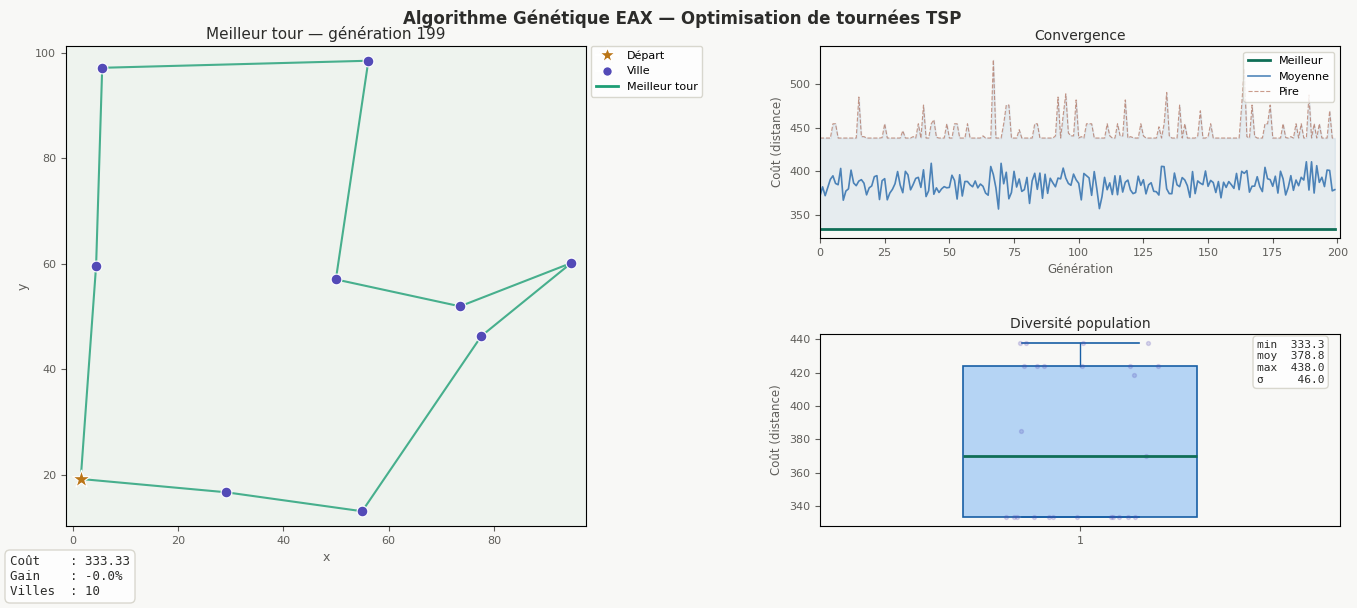


Meilleur tour trouvé : coût = 333.3339
Amélioration totale  : 333.33 → 333.33 (0.0% de gain)
Temps      : 0.590s
  Gén    0 | Best :     805.48 | Moy :     850.82 | Global :     805.48


KeyboardInterrupt: 

In [8]:
import time

villes = charger_villes_depuis_split(chunk_size=10, source="tsp")
print("Lancement de l'algorithme génétique EAX...")

t0 = time.perf_counter()
meilleur, historique = algorithme_genetique_eax(
    villes,
    taille_pop      = 25,
    nb_generations  = 200,
    taux_mutation   = 0.02,
    nb_elites       = 2,
    verbose         = True,
    affichage       = True,   # afficher la figure à la fin
)
elapsed = time.perf_counter() - t0

print(f"\nMeilleur tour trouvé : coût = {meilleur.cout():.4f}")
print(f"Amélioration totale  : {historique[0]:.2f} → {historique[-1]:.2f} "
    f"({(historique[0] - historique[-1]) / historique[0] * 100:.1f}% de gain)")
print(f"Temps      : {elapsed:.3f}s")

villes = charger_villes_depuis_split(chunk_size=100, source="tsp")
t0 = time.perf_counter()
meilleur, historique = algorithme_genetique_eax(
    villes,
    taille_pop      = 25,
    nb_generations  = 200,
    taux_mutation   = 0.02,
    nb_elites       = 2,
    verbose         = True,
    affichage       = True,   # afficher la figure à la fin
)
elapsed = time.perf_counter() - t0

print(f"\nMeilleur tour trouvé : coût = {meilleur.cout():.4f}")
print(f"Amélioration totale  : {historique[0]:.2f} → {historique[-1]:.2f} "
    f"({(historique[0] - historique[-1]) / historique[0] * 100:.1f}% de gain)")
print(f"Temps      : {elapsed:.3f}s")


  Gén    0 | Best :     478.75 | Moy :     522.35 | Global :     478.75
  Gén   20 | Best :     478.75 | Moy :     544.31 | Global :     478.75
  Gén   40 | Best :     478.75 | Moy :     525.15 | Global :     478.75
  Gén   60 | Best :     478.75 | Moy :     513.06 | Global :     478.75
  Gén   80 | Best :     478.75 | Moy :     523.91 | Global :     478.75
  Gén  100 | Best :     478.75 | Moy :     539.06 | Global :     478.75
  Gén  120 | Best :     478.75 | Moy :     506.80 | Global :     478.75
  Gén  140 | Best :     478.75 | Moy :     561.57 | Global :     478.75
  Gén  160 | Best :     478.75 | Moy :     514.32 | Global :     478.75
  Gén  180 | Best :     478.75 | Moy :     508.15 | Global :     478.75
  Gén  199 | Best :     478.75 | Moy :     520.84 | Global :     478.75


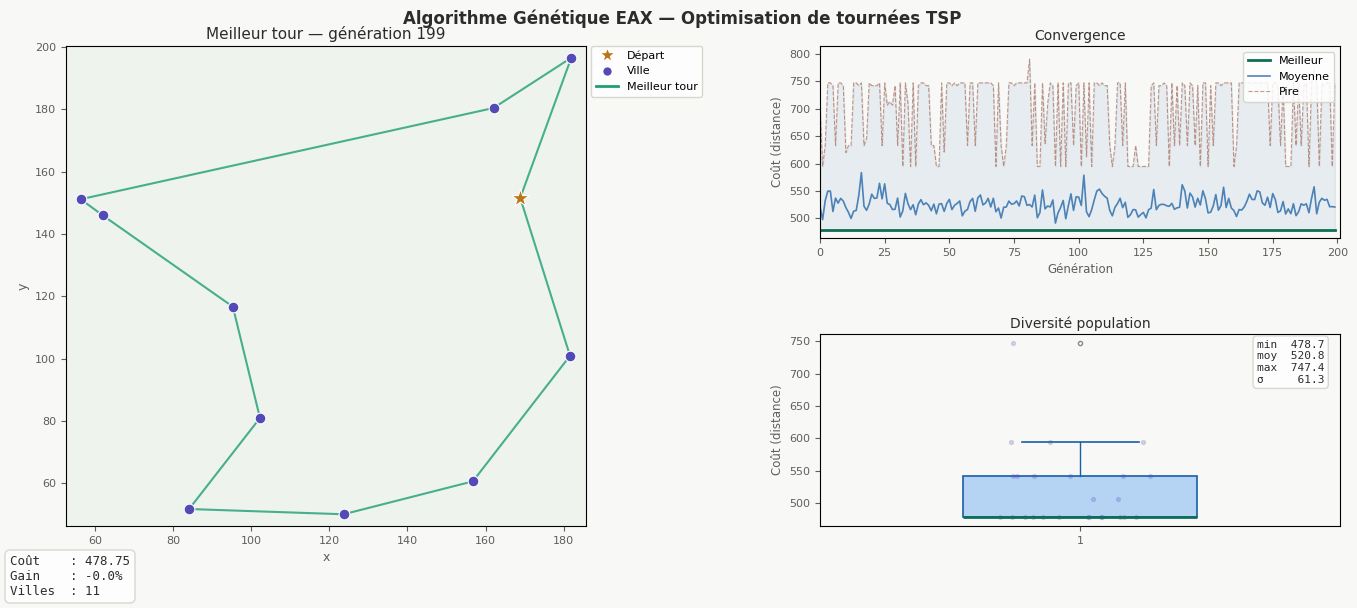

Temps      : 0.621s
  Gén    0 | Best :    1684.05 | Moy :    1761.21 | Global :    1684.05
  Gén   20 | Best :    1619.08 | Moy :    1736.95 | Global :    1619.08
  Gén   40 | Best :    1619.08 | Moy :    1808.52 | Global :    1619.08
  Gén   60 | Best :    1619.08 | Moy :    1732.46 | Global :    1619.08
  Gén   80 | Best :    1616.71 | Moy :    1805.08 | Global :    1616.71
  Gén  100 | Best :    1616.71 | Moy :    1755.03 | Global :    1616.71
  Gén  120 | Best :    1616.71 | Moy :    1834.39 | Global :    1616.71
  Gén  140 | Best :    1616.71 | Moy :    1778.18 | Global :    1616.71
  Gén  160 | Best :    1616.71 | Moy :    1707.92 | Global :    1616.71
  Gén  180 | Best :    1616.71 | Moy :    1707.18 | Global :    1616.71
  Gén  199 | Best :    1616.71 | Moy :    1752.89 | Global :    1616.71


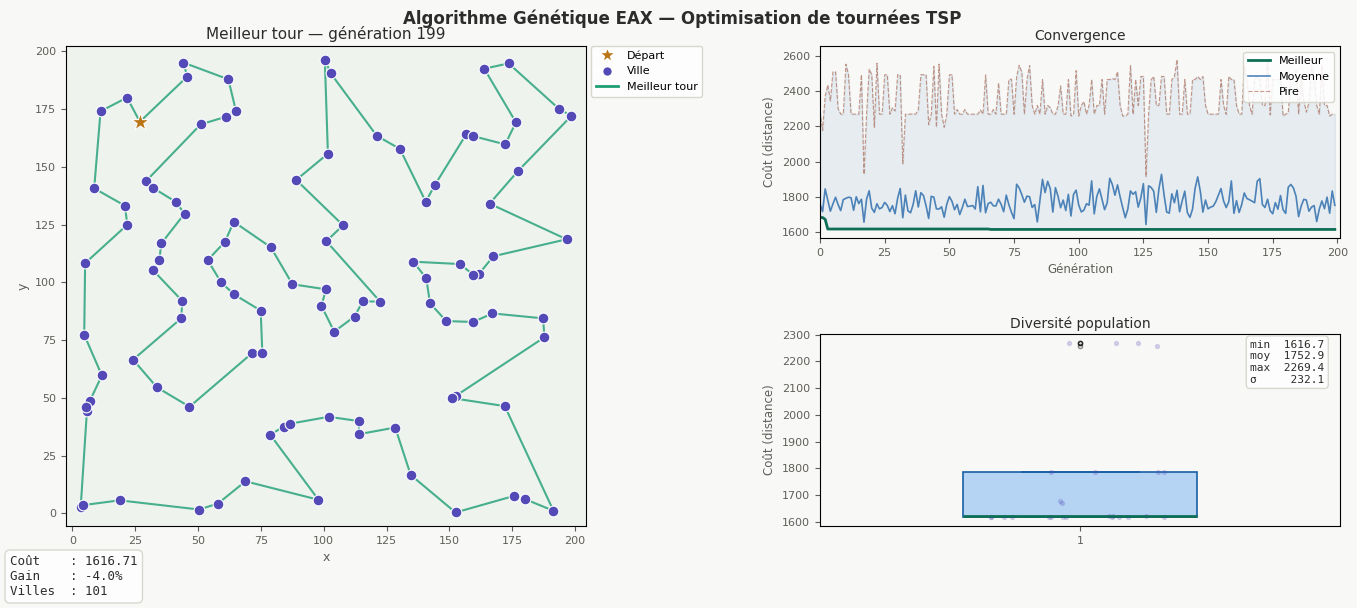

Temps      : 24.517s


In [9]:
villes = charger_villes_depuis_split(source="json", n_json=10)
# 2. Lancement de l'algorithme
t0 = time.perf_counter()
meilleur, historique = algorithme_genetique_eax(
    villes,
    taille_pop=25,
    nb_generations=200,
    affichage=True
)
elapsed = time.perf_counter() - t0
print(f"Temps      : {elapsed:.3f}s")

villes = charger_villes_depuis_split(source="json", n_json=100)
# 2. Lancement de l'algorithme
t0 = time.perf_counter()
meilleur, historique = algorithme_genetique_eax(
    villes,
    taille_pop=25,
    nb_generations=200,
    affichage=True
)
elapsed = time.perf_counter() - t0
print(f"Temps      : {elapsed:.3f}s")